In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from lmfit import Model
import pathlib as Path
from scipy.signal import savgol_filter

### Information of dataset
- there are 87 participants and at this time 5 variables (17 Aug)


### Data preperation steps
split the data in 80/20,
cross validation (CV)

1. Cleaning data
- Missing data
- Outliers
2. Formating
- Encoding categorical data
- Scaling data
- Standardization
- Discretization (binning data)
3. Data engineering

In [2]:
from pathlib import Path
x = Path('/Users/arthur/Library/Mobile Documents/com~apple~CloudDocs/Documents/Marseille/aMU/M1/Stage/2026_09_09_data_timeseries.csv')
df = pd.read_csv(x).drop(columns='Unnamed: 0')
df

,condition_id,condition,category,valence,time,LDX (pix),LDY (pix),RDX (pix),RDY (pix),RDX_rolling,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad
0,ACP_10,ACP,objet,negative,0.000000,-0.203103,10.545351,-1.557942,7.259980,-1.557942,-44.339866,329.0,-12.022054,1655.0,0.024372
1,ACP_10,ACP,objet,negative,0.003335,0.411109,11.118102,-0.912476,7.956384,-1.235209,-44.339866,329.0,-12.022054,1655.0,0.024372
2,ACP_10,ACP,objet,negative,0.006670,1.032096,11.620336,-0.216857,8.562834,-0.895758,-44.339866,329.0,-12.022054,1655.0,0.024372
3,ACP_10,ACP,objet,negative,0.010006,1.631694,11.941326,0.494356,8.978518,-0.548230,-44.339866,329.0,-12.022054,1655.0,0.024372
4,ACP_10,ACP,objet,negative,0.013341,2.171882,11.973220,1.177103,9.107632,-0.203163,-44.339866,329.0,-12.022054,1655.0,0.024372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933627,DFT_9,DFT,visage,positive,5.959993,NaN,NaN,-23.547614,NaN,-23.149807,-48.965409,317.0,-13.618955,1256.0,0.037643
933628,DFT_9,DFT,visage,positive,5.963328,NaN,NaN,-24.026216,NaN,-23.152393,-48.965409,317.0,-13.618955,1256.0,0.037643
933629,DFT_9,DFT,visage,positive,5.966663,NaN,NaN,-24.564667,NaN,-23.182579,-48.965409,317.0,-13.618955,1256.0,0.037643
933630,DFT_9,DFT,visage,positive,5.969998,NaN,NaN,-25.144319,NaN,-23.244083,-48.965409,317.0,-13.618955,1256.0,0.037643


In [3]:
df['RDX2_min'] = df['RDX_min']**2
df['RDX2_max'] = df['RDX_max']**2

df.head()

,condition_id,condition,category,valence,time,LDX (pix),LDY (pix),RDX (pix),RDY (pix),RDX_rolling,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad,RDX2_min,RDX2_max
0,ACP_10,ACP,objet,negative,0.000000,-0.203103,10.545351,-1.557942,7.259980,-1.557942,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776
1,ACP_10,ACP,objet,negative,0.003335,0.411109,11.118102,-0.912476,7.956384,-1.235209,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776
2,ACP_10,ACP,objet,negative,0.006670,1.032096,11.620336,-0.216857,8.562834,-0.895758,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776
3,ACP_10,ACP,objet,negative,0.010006,1.631694,11.941326,0.494356,8.978518,-0.548230,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776
4,ACP_10,ACP,objet,negative,0.013341,2.171882,11.973220,1.177103,9.107632,-0.203163,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776


##### Remove NaNs

In [4]:
rdx_data = df.dropna(subset=['RDX_rolling'], how='any')
rdx_data

,condition_id,condition,category,valence,time,LDX (pix),LDY (pix),RDX (pix),RDY (pix),RDX_rolling,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad,RDX2_min,RDX2_max
0,ACP_10,ACP,objet,negative,0.000000,-0.203103,10.545351,-1.557942,7.259980,-1.557942,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776
1,ACP_10,ACP,objet,negative,0.003335,0.411109,11.118102,-0.912476,7.956384,-1.235209,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776
2,ACP_10,ACP,objet,negative,0.006670,1.032096,11.620336,-0.216857,8.562834,-0.895758,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776
3,ACP_10,ACP,objet,negative,0.010006,1.631694,11.941326,0.494356,8.978518,-0.548230,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776
4,ACP_10,ACP,objet,negative,0.013341,2.171882,11.973220,1.177103,9.107632,-0.203163,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933627,DFT_9,DFT,visage,positive,5.959993,NaN,NaN,-23.547614,NaN,-23.149807,-48.965409,317.0,-13.618955,1256.0,0.037643,2397.611290,185.475945
933628,DFT_9,DFT,visage,positive,5.963328,NaN,NaN,-24.026216,NaN,-23.152393,-48.965409,317.0,-13.618955,1256.0,0.037643,2397.611290,185.475945
933629,DFT_9,DFT,visage,positive,5.966663,NaN,NaN,-24.564667,NaN,-23.182579,-48.965409,317.0,-13.618955,1256.0,0.037643,2397.611290,185.475945
933630,DFT_9,DFT,visage,positive,5.969998,NaN,NaN,-25.144319,NaN,-23.244083,-48.965409,317.0,-13.618955,1256.0,0.037643,2397.611290,185.475945


##### One hot encoder

In [5]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
ohetransform = ohe.fit_transform(rdx_data[['category', 'valence']])
rdx_data = pd.concat([rdx_data, ohetransform], axis=1).drop(columns=['category', 'valence'])
rdx_data

,condition_id,condition,time,LDX (pix),LDY (pix),RDX (pix),RDY (pix),RDX_rolling,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad,RDX2_min,RDX2_max,category_objet,category_visage,valence_negative,valence_neutre,valence_positive
0,ACP_10,ACP,0.000000,-0.203103,10.545351,-1.557942,7.259980,-1.557942,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776,1.0,0.0,1.0,0.0,0.0
1,ACP_10,ACP,0.003335,0.411109,11.118102,-0.912476,7.956384,-1.235209,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776,1.0,0.0,1.0,0.0,0.0
2,ACP_10,ACP,0.006670,1.032096,11.620336,-0.216857,8.562834,-0.895758,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776,1.0,0.0,1.0,0.0,0.0
3,ACP_10,ACP,0.010006,1.631694,11.941326,0.494356,8.978518,-0.548230,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776,1.0,0.0,1.0,0.0,0.0
4,ACP_10,ACP,0.013341,2.171882,11.973220,1.177103,9.107632,-0.203163,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933627,DFT_9,DFT,5.959993,NaN,NaN,-23.547614,NaN,-23.149807,-48.965409,317.0,-13.618955,1256.0,0.037643,2397.611290,185.475945,0.0,1.0,0.0,0.0,1.0
933628,DFT_9,DFT,5.963328,NaN,NaN,-24.026216,NaN,-23.152393,-48.965409,317.0,-13.618955,1256.0,0.037643,2397.611290,185.475945,0.0,1.0,0.0,0.0,1.0
933629,DFT_9,DFT,5.966663,NaN,NaN,-24.564667,NaN,-23.182579,-48.965409,317.0,-13.618955,1256.0,0.037643,2397.611290,185.475945,0.0,1.0,0.0,0.0,1.0
933630,DFT_9,DFT,5.969998,NaN,NaN,-25.144319,NaN,-23.244083,-48.965409,317.0,-13.618955,1256.0,0.037643,2397.611290,185.475945,0.0,1.0,0.0,0.0,1.0


##### Train, test, split

In [6]:
from sklearn.model_selection import GroupShuffleSplit

X = rdx_data.loc[:, ['RDX_min', 'RDX_lat_min', 'RDX_max', 'RDX_lat_max', 'RDX_grad', 'RDX2_min', 'RDX2_max', 'category_objet',  'category_visage', 'valence_negative',
   'valence_neutre', 'valence_positive']].iloc[0::1792, :].reset_index().drop(columns='index')
y = rdx_data.loc[:, 'condition'].iloc[0::1792].reset_index().drop(columns='index')

id = rdx_data.condition_id.iloc[0::1792].reset_index().drop(columns='index')

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in gss.split(X, groups=id):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    id_train = id.iloc[train_idx]
    id_test = id.iloc[test_idx]

### Cleaning data

##### Missing data

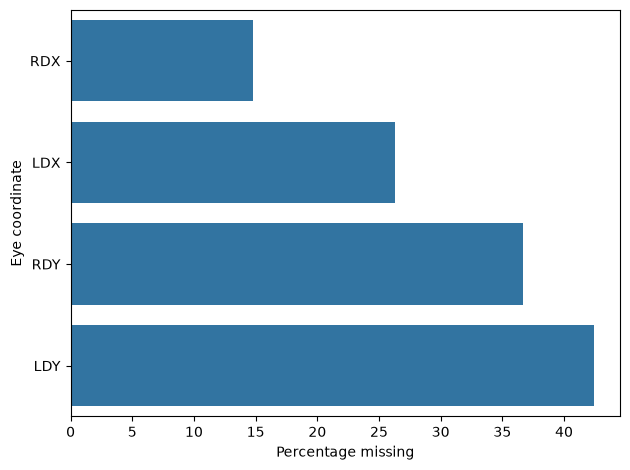

In [13]:
# highlight why RDX was chosen over the others
missing_values = {
    'RDX': df['RDX (pix)'].isna().mean()*100,
    'LDX': df['LDX (pix)'].isna().mean()*100,
    'RDY': df['RDY (pix)'].isna().mean()*100,
    'LDY': df['LDY (pix)'].isna().mean()*100
}


ax = sns.barplot(data = missing_values, orient='h')
ax.set(xlabel = 'Percentage missing', ylabel='Eye coordinate')
# plt.savefig('figures/missing_pupil.png', dpi=150)
plt.tight_layout()

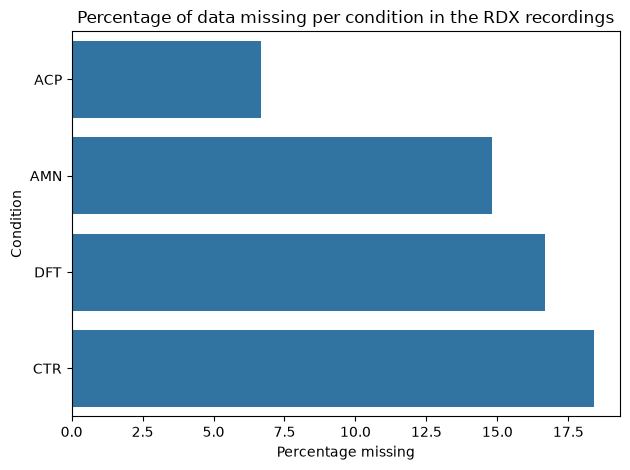

In [14]:
missing_values = {
    'ACP': df[df.condition=='ACP']['RDX (pix)'].isna().mean()*100,
    'AMN': df[df.condition=='AMN']['RDX (pix)'].isna().mean()*100,
    'DFT': df[df.condition=='DFT']['RDX (pix)'].isna().mean()*100,
    'CTR': df[df.condition=='CTR']['RDX (pix)'].isna().mean()*100
}


ax = sns.barplot(data = missing_values, orient='h')
ax.set(xlabel='Percentage missing', ylabel='Condition', title='Percentage of data missing per condition in the RDX recordings')
# plt.savefig('figures/missing_rdx.png', dpi=150)
plt.tight_layout()

##### Outliers

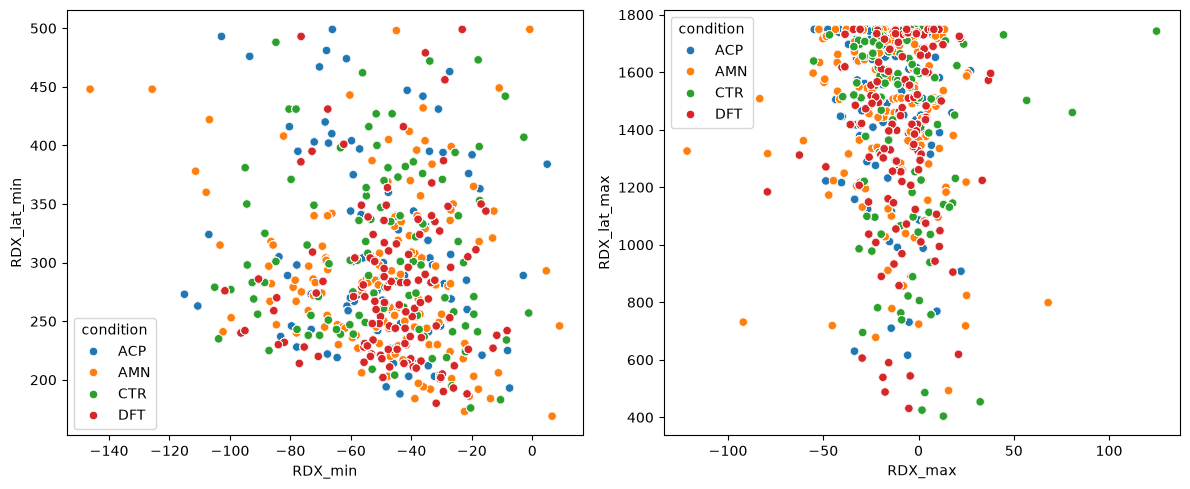

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))


sns.scatterplot(rdx_data, x='RDX_min', y='RDX_lat_min', ax=ax[0], hue='condition')
sns.scatterplot(rdx_data, x='RDX_max', y='RDX_lat_max', ax=ax[1], hue='condition')
plt.tight_layout()

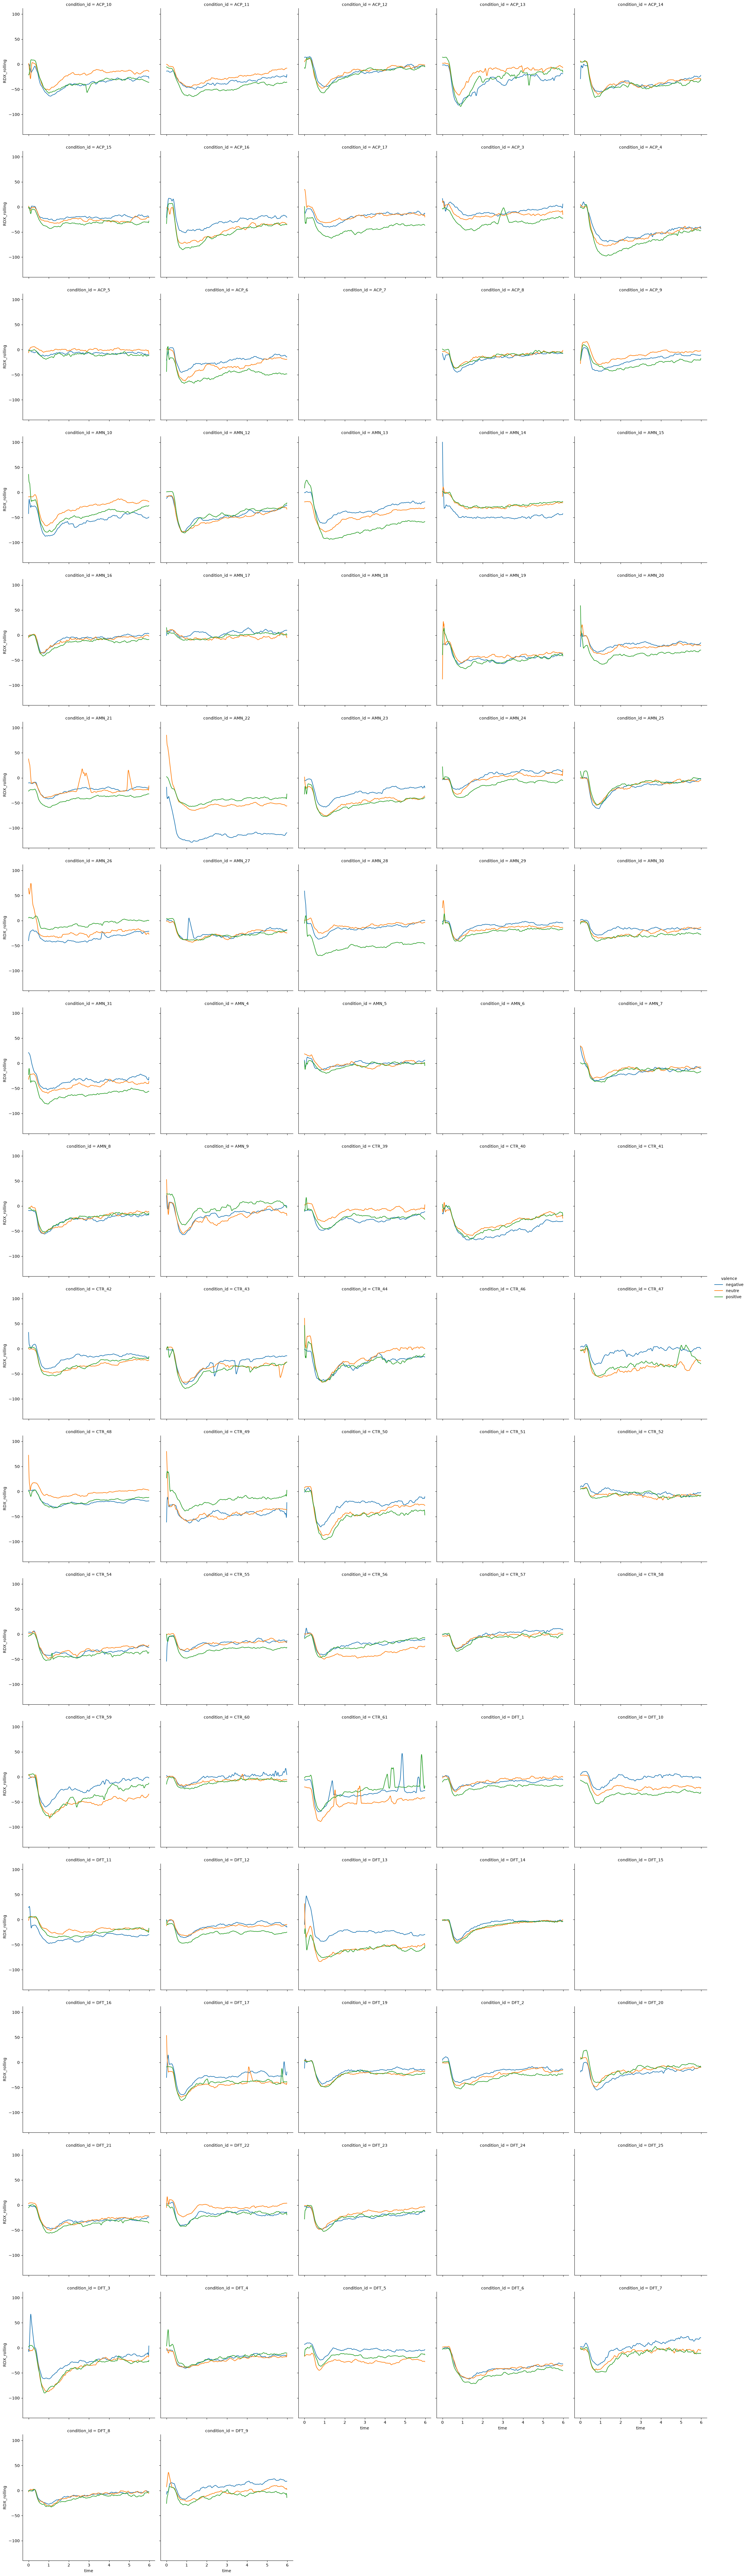

In [43]:
sns.relplot(df, x='time', y='RDX_rolling', col_wrap=5, col='condition_id', hue='valence', kind='line', errorbar=None)

##### Isolation Forest

In [39]:
from sklearn.ensemble import IsolationForest

X = rdx_data.loc[:, ['RDX_min', 'RDX_lat_min', 'RDX_max', 'RDX_lat_max', 'RDX_grad', 'RDX2_min', 'RDX2_max']]

clf = IsolationForest(max_samples=100, random_state=0)
clf.fit(X)

,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",100
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",0
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...andom_state=0)


In [41]:
from sklearn.inspection import DecisionBoundaryDisplay

disp = DecisionBoundaryDisplay.from_estimator(
    clf,
    X.loc[:, ['RDX_min', 'RDX_lat_min']],
    response_method="predict",
    alpha=0.5,
)
disp.ax_.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor="k")
disp.ax_.set_title("Binary decision boundary \nof IsolationForest")
plt.axis("square")
plt.show()

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- RDX2_max
- RDX2_min
- RDX_grad
- RDX_lat_max
- RDX_max


<Axes: >

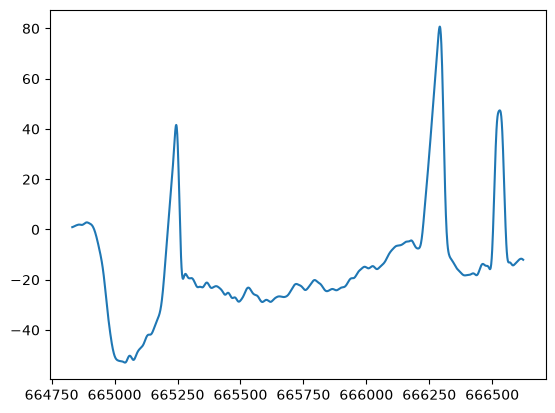

In [48]:
rdx_data[(rdx_data.condition_id=='CTR_61') & (rdx_data.category_objet==1.0) & (rdx_data.valence_negative==1.0)]['RDX_rolling'].plot()

In [49]:
from sklearn.ensemble import IsolationForest

# Feature selection: We'll use only the 'Cost(€/MWh)' column for anomaly detection
X = rdx_data[(rdx_data.condition_id=='CTR_61') & (rdx_data.category_objet==1.0) & (rdx_data.valence_negative==1.0)]['RDX_rolling']

# Initialize the Isolation Forest model
model = IsolationForest(contamination=0.05, random_state=42)  # Adjust contamination as needed

# Fit the model
model.fit(X)

# Predict anomalies (1 for normal, -1 for anomalies)
model.predict(X)

# # Visualize anomalies
# plt.figure(figsize=(20, 6))
# plt.plot(df_France['Datetime'], df_France['Cost(€/MWh)'], label='Cost(€/MWh)')
# plt.scatter(df_France['Datetime'][df_France['Anomaly'] == -1], df_France['Cost(€/MWh)'][df_France['Anomaly'] == -1], color='red', label='Anomalies')
# plt.xlabel('DateTime')
# plt.ylabel('RDX')
# plt.title('Anomaly Detection using Isolation Forest')
# plt.legend()
# plt.show()

ValueError: Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

<Axes: >

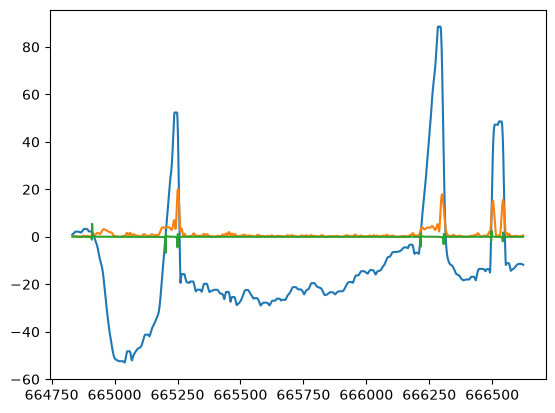

In [62]:
rdx_data[(rdx_data.condition_id=='CTR_61') & (rdx_data.category_objet==1.0) & (rdx_data.valence_negative==1.0)]['RDX (pix)'].rolling(window=10, min_periods=1).max().plot()
# rdx_data[(rdx_data.condition_id=='CTR_61') & (rdx_data.category_objet==1.0) & (rdx_data.valence_negative==1.0)]['RDX (pix)'].rolling(window=10, min_periods=1).min().plot()
# rdx_data[(rdx_data.condition_id=='CTR_61') & (rdx_data.category_objet==1.0) & (rdx_data.valence_negative==1.0)]['RDX (pix)'].rolling(window=10, min_periods=1).mean().plot()
rdx_data[(rdx_data.condition_id=='CTR_61') & (rdx_data.category_objet==1.0) & (rdx_data.valence_negative==1.0)]['RDX (pix)'].rolling(window=10, min_periods=1).std().plot()
# rdx_data[(rdx_data.condition_id=='CTR_61') & (rdx_data.category_objet==1.0) & (rdx_data.valence_negative==1.0)]['RDX (pix)'].shift(1).plot()
# rdx_data[(rdx_data.condition_id=='CTR_61') & (rdx_data.category_objet==1.0) & (rdx_data.valence_negative==1.0)]['RDX (pix)'].shift(5).plot()
rdx_data[(rdx_data.condition_id=='CTR_61') & (rdx_data.category_objet==1.0) & (rdx_data.valence_negative==1.0)]['RDX (pix)'].pct_change().plot()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import RobustScaler
import warnings


# ---------------------------------------------------
# Step 2: Create Features
# ---------------------------------------------------

def create_features(group):
    """
    Create rolling and lag features for each group identified by 'id'.
    
    Parameters:
    - group: pandas DataFrame representing a single group based on 'id'
    
    Returns:
    - group: pandas DataFrame with new features added
    """
    # Sort the group by 'datetime' to ensure chronological order
    group = group.sort_values("datetime")
    
    # Calculate rolling mean with a window of 10, minimum 1 period to avoid NaN
    group["rolling_mean"] = group["value"].rolling(window=10, min_periods=1).mean()
    
    # Calculate rolling standard deviation with a window of 10, minimum 1 period
    group["rolling_std"] = group["value"].rolling(window=10, min_periods=1).std()
    
    # Calculate rolling maximum with a window of 10, minimum 1 period
    group["rolling_max"] = group["value"].rolling(window=10, min_periods=1).max()
    
    # Calculate rolling minimum with a window of 10, minimum 1 period
    group["rolling_min"] = group["value"].rolling(window=10, min_periods=1).min()
    
    # Create lag features: value shifted by 1
    group["lag_1"] = group["value"].shift(1)
    
    # Create lag features: value shifted by 5
    group["lag_5"] = group["value"].shift(5)
    
    # Calculate the percentage change from the previous value
    group["pct_change"] = group["value"].pct_change()
    
    return group

# ---------------------------------------------------
# Step 3: Process Data by Group
# ---------------------------------------------------

# Convert 'datetime' column to datetime objects for proper sorting and manipulation
data["datetime"] = pd.to_datetime(data["datetime"])

# Apply the 'create_features' function to each group identified by 'id'
# This adds the new rolling and lag features to the dataset
data = data.groupby("id").apply(create_features).reset_index(drop=True)

# ---------------------------------------------------
# Step 4: Handle Infinite Values and Missing Data
# ---------------------------------------------------

# Define the list of feature columns to be used for modeling
feature_cols = [
    "value",
    "rolling_mean",
    "rolling_std",
    "rolling_max",
    "rolling_min",
    "lag_1",
    "lag_5",
    "pct_change",
]

# Replace infinite values with NaN to handle anomalies in data
data[feature_cols] = data[feature_cols].replace([np.inf, -np.inf], np.nan)

# Forward fill NaN values to propagate the last valid observation forward
# Then backward fill any remaining NaNs to ensure no missing values remain
data[feature_cols] = data[feature_cols].fillna(method="ffill").fillna(method="bfill")

# ---------------------------------------------------
# Step 5: Scale Features
# ---------------------------------------------------

# Initialize RobustScaler to scale features while being robust to outliers
scaler = RobustScaler()

# Fit the scaler on the feature matrix and transform the features accordingly
X = scaler.fit_transform(data[feature_cols])

# ---------------------------------------------------
# Step 6: Calculate Dynamic Contamination Rate
# ---------------------------------------------------

def estimate_contamination(X):
    """
    Estimate the contamination rate based on the proportion of outliers in each feature.
    
    Parameters:
    - X: numpy array of feature values
    
    Returns:
    - average_contamination: float representing the average contamination rate across features
    """
    outlier_proportions = []
    for feature_idx in range(X.shape[1]):
        # Extract all values for the current feature
        feature_values = X[:, feature_idx]
        
        # Calculate mean and standard deviation of the feature
        mean = np.mean(feature_values)
        std = np.std(feature_values)
        
        # Count the number of outliers beyond 3 standard deviations from the mean
        outliers = np.sum(np.abs(feature_values - mean) > 3 * std)
        
        # Calculate the proportion of outliers in the current feature
        outlier_proportions.append(outliers / len(feature_values))
    
    # Return the average contamination rate across all features
    return np.mean(outlier_proportions)

# Estimate the contamination rate using the defined function
contamination = estimate_contamination(X)

# Bound the contamination rate between 1% and 20% to ensure reasonable model assumptions
contamination = min(max(contamination, 0.01), 0.2)  # Bound between 1% and 20%

# ---------------------------------------------------
# Step 7: Train/Validation Split
# ---------------------------------------------------

# Split the dataset into training and validation sets with an 80-20 split
# This ensures that the model is trained on a majority of the data and validated on a representative subset
X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)

# ---------------------------------------------------
# Step 8: Train Isolation Forest with Dynamic Contamination
# ---------------------------------------------------

# Initialize the Isolation Forest model with the estimated contamination rate
# - 'random_state=42' ensures reproducibility
clf = IsolationForest(contamination=contamination, random_state=42)

# Fit the Isolation Forest model on the training data to learn the patterns of normal instances
clf.fit(X_train)

# ---------------------------------------------------
# Step 9: Make Predictions
# ---------------------------------------------------

# Predict anomalies on the training set
train_pred = clf.predict(X_train)

# Predict anomalies on the validation set
val_pred = clf.predict(X_val)

# ---------------------------------------------------
# Step 10: Convert Predictions to Binary Labels
# ---------------------------------------------------

# Convert predictions to binary format: 1 for normal instances, 0 for anomalies
train_pred = [1 if x == 1 else 0 for x in train_pred]
val_pred = [1 if x == 1 else 0 for x in val_pred]

# ---------------------------------------------------
# Step 11: Generate Synthetic Labels for Demonstration
# ---------------------------------------------------

# Generate synthetic true labels for the validation set for demonstration purposes
# Here, 90% of the instances are considered normal (1) and 10% as anomalies (0)
np.random.seed(42)
val_true = np.random.binomial(n=1, p=0.9, size=len(val_pred))

# ---------------------------------------------------
# Step 12: Calculate F1 Score
# ---------------------------------------------------

# Calculate the F1 score to evaluate the model's performance on the validation set
# - F1 score is the harmonic mean of precision and recall
f1 = f1_score(val_true, val_pred)
print(f"F1 Score: {f1:.4f}")

# ---------------------------------------------------
# Step 13: Save Predictions
# ---------------------------------------------------

# Predict anomalies on the entire dataset using the trained Isolation Forest model
data["anomaly"] = clf.predict(X)

# Map the predictions to binary labels: 0 for normal instances, 1 for anomalies
data["anomaly"] = data["anomaly"].map({1: 0, -1: 1})  # Convert to 0 (normal) and 1 (anomaly)

# Create a submission DataFrame containing 'datetime', 'id', and 'anomaly' labels
submission = data[["datetime", "id", "anomaly"]]

# Save the submission DataFrame to a CSV file without the index
submission.to_csv("/kaggle/working/submission.csv", index=False)

##### Scaling

In [16]:
from sklearn.preprocessing import RobustScaler

before_scaled = X_train.copy()

transformer = RobustScaler().set_output(transform="pandas").fit(X_train.loc[:, ['RDX_min', 'RDX_lat_min', 'RDX_max', 'RDX_lat_max', 'RDX_grad', 'RDX2_min', 'RDX2_max']])
X_train = transformer.transform(X_train.loc[:, ['RDX_min', 'RDX_lat_min', 'RDX_max', 'RDX_lat_max', 'RDX_grad', 'RDX2_min', 'RDX2_max']])

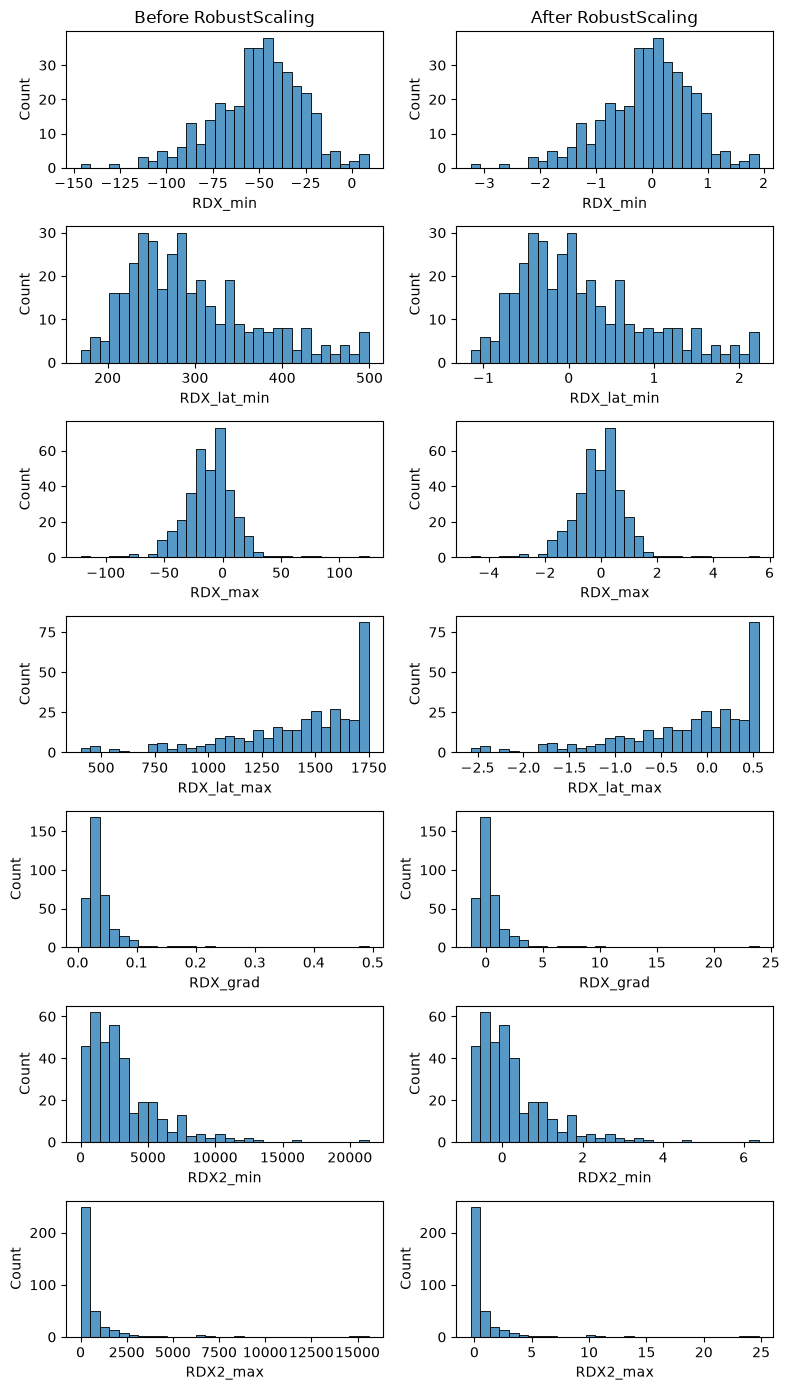

In [18]:
fig, ax = plt.subplots(7, 2, figsize=(8, 14))

sns.histplot(before_scaled, x='RDX_min', bins=30, ax=ax[0][0])
sns.histplot(X_train, x='RDX_min', bins=30, ax=ax[0][1])

sns.histplot(before_scaled, x='RDX_lat_min', bins=30, ax=ax[1][0])
sns.histplot(X_train, x='RDX_lat_min', bins=30, ax=ax[1][1])

sns.histplot(before_scaled, x='RDX_max', bins=30, ax=ax[2][0])
sns.histplot(X_train, x='RDX_max', bins=30, ax=ax[2][1])

sns.histplot(before_scaled, x='RDX_lat_max', bins=30, ax=ax[3][0])
sns.histplot(X_train, x='RDX_lat_max', bins=30, ax=ax[3][1])

sns.histplot(before_scaled, x='RDX_grad', bins=30, ax=ax[4][0])
sns.histplot(X_train, x='RDX_grad', bins=30, ax=ax[4][1])

sns.histplot(before_scaled, x='RDX2_min', bins=30, ax=ax[5][0])
sns.histplot(X_train, x='RDX2_min', bins=30, ax=ax[5][1])

sns.histplot(before_scaled, x='RDX2_max', bins=30, ax=ax[6][0])
sns.histplot(X_train, x='RDX2_max', bins=30, ax=ax[6][1])

ax[0][0].set_title('Before RobustScaling')
ax[0][1].set_title('After RobustScaling')

plt.tight_layout()

In [15]:
X_train.describe().round(3)

,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad
count,354.000,354.000,354.000,354.000,354.000
mean,-0.067,0.155,-0.059,-0.193,0.446
std,0.784,0.755,0.958,0.723,1.843
min,-3.248,-1.151,-4.650,-2.576,-1.333
25%,-0.538,-0.402,-0.544,-0.590,-0.364
50%,0.000,0.000,-0.000,0.000,0.000
75%,0.462,0.598,0.456,0.410,0.636
max,1.911,2.225,5.611,0.559,23.934


##### Checking features - correlation

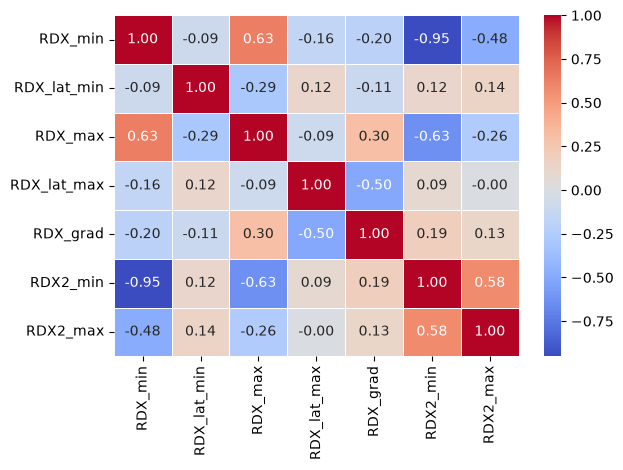

In [19]:
matrix = X_train.loc[:, ['RDX_min', 'RDX_lat_min', 'RDX_max', 'RDX_lat_max', 'RDX_grad', 'RDX2_min', 'RDX2_max']].corr()
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.tight_layout()

##### Checking features - PCA

In [20]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_train)

In [21]:
pca.explained_variance_ratio_

array([0.52034615, 0.28076723, 0.10765553, 0.04364726, 0.03578181,
       0.00968286, 0.00211915])

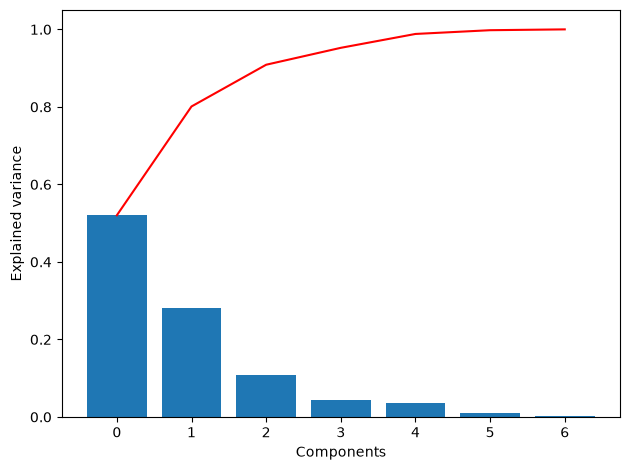

In [22]:
plt.bar(range(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_)
plt.plot(range(len(pca.explained_variance_ratio_)), np.cumsum(pca.explained_variance_ratio_), c='r')
plt.xlabel('Components')
plt.ylabel('Explained variance')
plt.tight_layout()

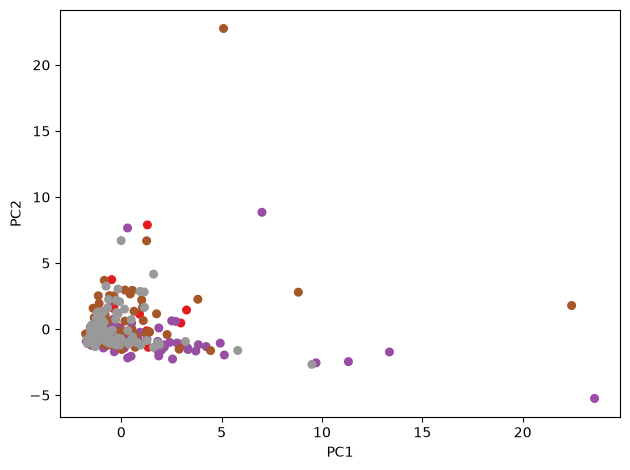

In [23]:
codes, _ = pd.factorize(y_train.loc[:, 'condition'])
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=codes, s=30, cmap="Set1")
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()

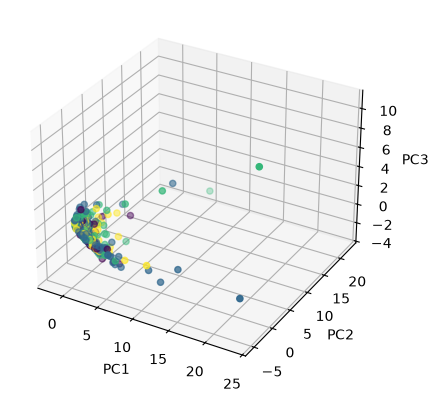

In [24]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=codes)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

plt.show()

In [28]:
save = rdx_data.loc[:, ['condition', 'condition_id', 'RDX_min', 'RDX_lat_min', 'RDX_max', 'RDX_lat_max', 'RDX_grad', 'RDX2_min', 'RDX2_max', 'category_objet',  'category_visage', 'valence_negative',
   'valence_neutre', 'valence_positive']]

save.to_csv('2026_09_09_variable_trainingset_2.csv')